# Hold out a category and search
Strategy 01 answers the founding question: is there a combination of measurements and map settings under which a label nobody showed the map falls out as clusters? This notebook runs it on the hyperLOPIT compartment.


In [1]:
from starplast import strategies as S
s = S.get('holdout_search')
s

Strategy(key='holdout_search', number=1, title='Hold out a category and search for a map that finds it', family='Search the map space', question='Is there a combination of measurements and map settings under which a label nobody showed the map falls out as clusters -- and which unlabelled genes land in them?', tooltip='Hides one label entirely, walks feature sets and UMAP/HDBSCAN settings, and keeps the map whose clusters best recover that label; unlabelled genes in its pure clusters become cand

In [2]:
s.parameters(S.shipped('Tg'))

name,label,kind,default,why
target,Held-out label,category,compartment,"The label the strategy is scored against and never allowed to see: the column itself, anything that restates it and the experiment that produced it are removed first, by the same closure the Search tab uses."
n_neighbors,UMAP neighbours to try,grid,"15, 50",Comma-separated UMAP n_neighbors values to walk. Small values keep local detail such as complexes; large values keep the global arrangement such as organelles. Every value multiplies the number of maps built.
min_dist,UMAP min_dist to try,grid,"0.0, 0.25","Comma-separated UMAP min_dist values to walk. Zero packs similar genes tightly, which clusters well; larger values spread them out, which reads better and clusters worse. Every value multiplies the number of maps."
min_cluster_size,Cluster sizes to try,grid,"20, 50",Comma-separated HDBSCAN minimum cluster sizes. Small values find small complexes and also split organelles; large values find organelles and swallow complexes. Cheap to widen: clustering is fast next to embedding.
selection,Cluster selection to try,grid,"eom, leaf","HDBSCAN's cluster selection, comma-separated: 'eom' keeps the most persistent clusters -- on the real proteome two to six very large ones -- and 'leaf' every leaf of the cluster tree, dozens of small purer clusters with more genes left as noise. Walking both costs little."
sample,Genes per map,int,3000,"How many genes each map embeds. Zero embeds all of them; a sample of a few thousand makes a walk of many maps finish in minutes rather than an hour, at the cost of saying nothing about the genes left out."
features,Feature sets,choice,all,"'all' walks one map per setting from every permitted measurement; 'families' also walks each kind of measurement alone, so you learn which evidence carries the label -- at several times the cost."
min_f1,Call a label's cluster at F1,float,0.2,Each label's best cluster names its unlabelled members only if it isolates that label at least this well on the known genes. Lower names more clusters and is wrong more often; every call carries its cluster's F1 as its support.


## Test before you run
The self-test hides 25% of the compartment labels (whole orthogroups together), lets the search choose the map and each label's cluster on the rest, and scores how well those clusters hold the hidden genes -- against the same search made on shuffled labels.


In [3]:
test = S.test('holdout_search', target='compartment', n_neighbors='15, 50',
              min_dist='0.0', min_cluster_size='20, 50', selection='eom, leaf')
test

TestResult(strategy='holdout_search', metric='F1 of hidden genes in the cluster chosen for their label on known genes', observed=0.13785080340603126, null=[0.04987677626864627, 0.08206852441257238, 0.055128970119269066, 0.04889391497017468, 0.0534686839143955, 0.06683347654688482, 0.061119692724949076, 0.05241409382446964, 0.04325265526301634, 0.052250235790676114, 0.053121776851763634, 0.06222351491733656, 0.04806039646297069, 0.06936920029836484, 0.04428062869772733, 0.055290920719761966, 0.06

## Run it


In [4]:
result = S.run('holdout_search', target='compartment', n_neighbors='15, 50',
                min_dist='0.0', min_cluster_size='20, 50', selection='eom, leaf',
                sample=2000)
print(result.summary)

Best of 8 configurations: all permitted, n_neighbors 50, min_dist 0.0, min cluster 20 (leaf). Mean F1 0.284 over the compartment labels, against 0.166 ± 0.009 for the same clustering with the labels shuffled; 1 label(s) recovered at F1 >= 0.5, best mitochondrion - membranes at 0.50. 67 unlabelled genes sit in the cluster that best isolates a label at F1 >= 0.20, and are called with it; 'support' is that F1.


In [5]:
result.tables['configurations'].head(8)

features,n_neighbors,min_dist,min_cluster_size,selection,clusters,noise,mean_f1,best_f1,best_label,labels_recovered
all permitted,50,0,20,leaf,13,0.645,0.284,0.5,mitochondrion - membranes,1
all permitted,15,0,20,leaf,14,0.552,0.28,0.548,mitochondrion - membranes,2
all permitted,50,0,50,leaf,5,0.327,0.259,0.436,nucleus - chromatin,0
all permitted,15,0,50,leaf,7,0.532,0.251,0.331,cytosol,0
all permitted,50,0,20,eom,8,0.455,0.235,0.31,dense granules,0
all permitted,15,0,50,eom,4,0.199,0.224,0.413,nucleus - chromatin,0
all permitted,50,0,50,eom,4,0.217,0.221,0.424,nucleus - chromatin,0
all permitted,15,0,20,eom,10,0.334,0.214,0.478,rhoptries 2,0


In [6]:
result.tables['label clusters']

label,cluster,n_label,n_in_cluster,precision,recall,f1_on_known_genes
mitochondrion - membranes,4,27,12,0.571,0.444,0.5
mitochondrion - soluble,8,45,17,0.321,0.378,0.347
dense granules,2,26,22,0.193,0.846,0.314
nucleus - chromatin,10,88,20,0.465,0.227,0.305
cytosol,5,63,16,0.327,0.254,0.286
apicoplast,12,28,6,0.316,0.214,0.255
Golgi,9,24,11,0.141,0.458,0.216


In [7]:
result.tables['calls'].head(10)

gene_id,product,prediction,support,cluster
TGME49_310360,ATP synthase-associated protein,mitochondrion - membranes,0.5,4
TGME49_310470,cytochrome c oxidase subunit COX2b,mitochondrion - membranes,0.5,4
TGME49_273815,hypothetical protein,mitochondrion - soluble,0.347,8
TGME49_208090,5-formyltetrahydrofolate cyclo-ligase,mitochondrion - soluble,0.347,8
TGME49_243240,"WD domain, G-beta repeat-containing protein",mitochondrion - soluble,0.347,8
TGME49_248770,hypothetical protein,mitochondrion - soluble,0.347,8
TGME49_254280,DNA-directed RNA polymerase III RPC9,mitochondrion - soluble,0.347,8
TGME49_301300,PHAX RNA-binding domain protein,mitochondrion - soluble,0.347,8
TGME49_225720,hypothetical protein,mitochondrion - soluble,0.347,8
TGME49_264010,"U4/U6.U5 small nuclear ribonucleoprotein, putative",mitochondrion - soluble,0.347,8


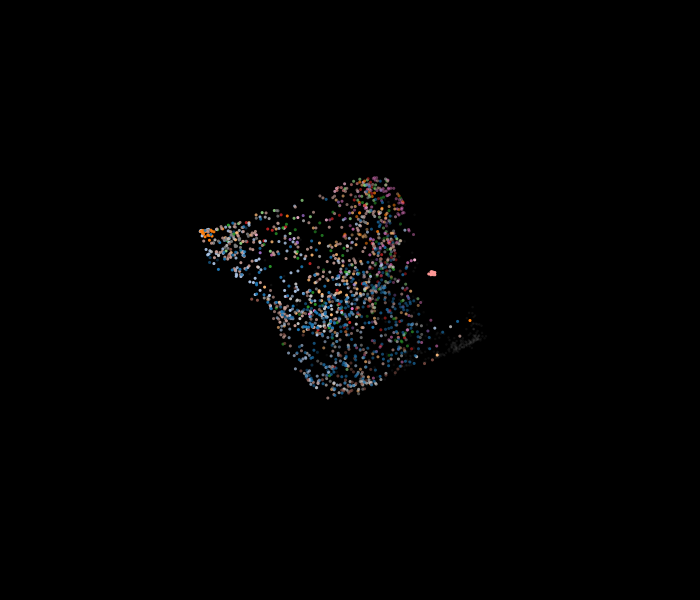

In [8]:
import matplotlib.pyplot as plt
plt.style.use('dark_background')
ax = result.plot(S.shipped('Tg'), color='compartment')
ax.figure